# `mimo_ar2ir` demo

Quick demo of the multivariate AR-coefficients → impulse-response function `ga.filters.tib.mimo_ar2ir`. Build a small VAR, run it, and look at the IR. Math: `docs/derivations/07-mimo-ar-to-ir.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ga.filters.tib import mimo_ar2ir

## Build a small VAR(2) and run `mimo_ar2ir`

In [2]:
rng = np.random.default_rng(0)
d, p, m = 3, 2, 40                       # 3 series, VAR(2), 40 IR lags
A = rng.standard_normal((p, d, d)) * 0.3 # matrix AR coeffs A_1, A_2 (scaled for stability)

h = mimo_ar2ir(A, m)                     # impulse response, shape (m, d, d)
print('AR coeffs shape:', A.shape, ' ->  IR shape:', h.shape)
print('h[0] (expect identity):\n', np.round(h[0], 3))
print('h[1] should equal A_1 -> max|h[1] - A_1| =', np.max(np.abs(h[1] - A[0])))

AR coeffs shape: (2, 3, 3)  ->  IR shape: (40, 3, 3)
h[0] (expect identity):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
h[1] should equal A_1 -> max|h[1] - A_1| = 0.0


In [3]:
h

array([[[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[ 3.77190663e-02, -3.96314590e-02,  1.92126795e-01],
        [ 3.14700351e-02, -1.60700812e-01,  1.08478516e-01],
        [ 3.91200014e-01,  2.84124289e-01, -2.11120571e-01]],

       [[-3.04290912e-01, -1.27520504e-01, -2.52164434e-02],
        [-6.58942675e-01, -1.02385703e-02, -4.08061679e-01],
        [-2.78573476e-01, -2.84425008e-01,  5.56632347e-02]],

       [[-5.42376172e-02, -1.04339724e-02, -6.99220696e-02],
        [-1.08497785e-01, -1.01228492e-01,  8.60130308e-03],
        [-2.97993111e-01,  1.52374589e-02, -1.77441897e-01]],

       [[ 1.80275494e-01,  5.33441415e-02,  4.94936368e-02],
        [ 3.43023365e-01,  2.13521312e-01,  7.36100084e-04],
        [ 2.11739045e-01,  2.06143787e-02,  7.94369959e-02]],

       [[ 7.10687971e-02,  2.05883674e-02,  3.98357431e-02],
        [ 1.29

## Impulse-response decay and per-channel entries

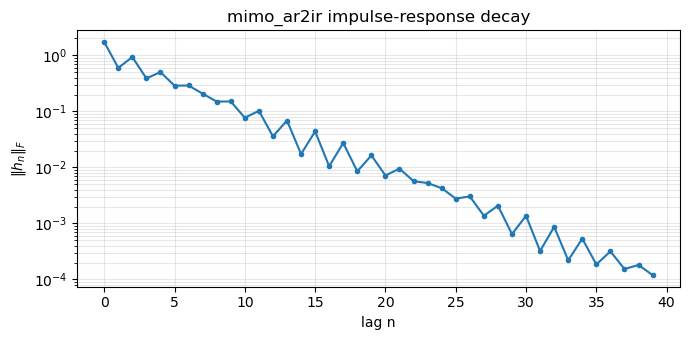

In [4]:
energy = np.linalg.norm(h, axis=(1, 2))   # ||h_n||_F per lag
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(energy, 'o-', ms=3)
ax.set_xlabel('lag n'); ax.set_ylabel(r'$\|h_n\|_F$')
ax.set_title('mimo_ar2ir impulse-response decay'); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout(); plt.show()

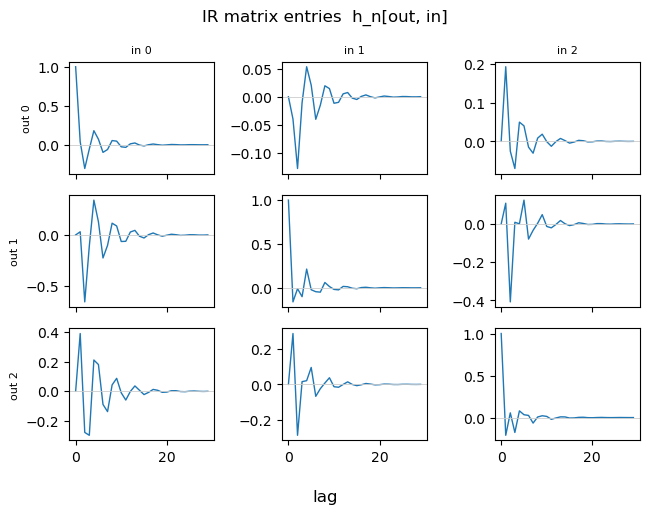

In [5]:
show = min(30, m)
fig, axes = plt.subplots(d, d, figsize=(2.2*d, 1.7*d), sharex=True)
for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        ax.plot(np.arange(show), h[:show, i, j], lw=1)
        ax.axhline(0, color='0.8', lw=0.6)
        if i == 0: ax.set_title(f'in {j}', fontsize=8)
        if j == 0: ax.set_ylabel(f'out {i}', fontsize=8)
fig.supxlabel('lag'); fig.suptitle('IR matrix entries  h_n[out, in]')
fig.tight_layout(); plt.show()

## Light sanity glance (not a proof)

The IR should invert the AR polynomial — convolving `[I, -A_1, -A_2]` with `h` ≈ `[I, 0, 0, …]`.

In [6]:
Acal = [np.eye(d)] + [-A[k] for k in range(p)]
resid = []
for n in range(m):
    s = sum(Acal[k] @ h[n-k] for k in range(0, min(n, p)+1))
    s = s - (np.eye(d) if n == 0 else 0.0)
    resid.append(np.max(np.abs(s)))
print('max convolution residual  max|(A*h) - delta*I| =', max(resid))   # ~1e-16 looks right

max convolution residual  max|(A*h) - delta*I| = 5.551115123125783e-17


## Scalar `d=1` reduces to a familiar AR(1) IR

In [7]:
a = 0.7
h1 = mimo_ar2ir(np.array([[[a]]]), 8).ravel()   # AR(1) with coefficient a
print('mimo_ar2ir d=1, AR(1) a=0.7:', np.round(h1, 4))
print('a**n (expected)           :', np.round(a ** np.arange(8), 4))

mimo_ar2ir d=1, AR(1) a=0.7: [1.     0.7    0.49   0.343  0.2401 0.1681 0.1176 0.0824]
a**n (expected)           : [1.     0.7    0.49   0.343  0.2401 0.1681 0.1176 0.0824]


## Validation (independent cross-checks)

The `𝒜(z)·H(z) = I` residual *is* the correctness criterion (the IR of `𝒜⁻¹` is unique), so a machine-precision residual is conclusive. The checks below confirm it across shapes/seeds and against independent methods. Math: `docs/derivations/07-mimo-ar-to-ir.md`.

In [8]:
def conv_resid(A, h, p, dd):
    Acal = [np.eye(dd)] + [-A[k] for k in range(p)]
    return max(np.max(np.abs(sum(Acal[k] @ h[n-k] for k in range(0, min(n, p)+1))
                             - (np.eye(dd) if n == 0 else 0.0))) for n in range(len(h)))

# (1) property sweep: 𝒜H=I over 50 random (d,p,m), including p>=m
worst = 0.0
for seed in range(50):
    g = np.random.default_rng(seed)
    dd = int(g.integers(1,6)); pp = int(g.integers(1,6)); mm = int(g.integers(2,60))
    Asw = g.standard_normal((pp,dd,dd)) * (0.5/pp)
    worst = max(worst, conv_resid(Asw, mimo_ar2ir(Asw, mm), pp, dd))
print(f'(1) property sweep 𝒜H=I over 50 random (d,p,m, incl. p>=m): worst residual = {worst:.1e}')

(1) property sweep 𝒜H=I over 50 random (d,p,m, incl. p>=m): worst residual = 5.6e-17


In [9]:
# (2) VAR(1) closed form: h_n must equal matrix power A1**n
g = np.random.default_rng(7); A1 = g.standard_normal((4,4))*0.3
hv = mimo_ar2ir(A1[None], 25)
err = max(np.max(np.abs(hv[n] - np.linalg.matrix_power(A1, n))) for n in range(25))
print(f'(2) VAR(1): mimo_ar2ir vs matrix_power(A1, n)  max err = {err:.1e}')

(2) VAR(1): mimo_ar2ir vs matrix_power(A1, n)  max err = 3.5e-18


In [10]:
# (3) independent dense block-Toeplitz solve  T_𝒜 h = E1
g = np.random.default_rng(3); dd,pp,mm = 3,3,20; At = g.standard_normal((pp,dd,dd))*0.2
ht = mimo_ar2ir(At, mm)
T = np.zeros((mm*dd, mm*dd))
for i in range(mm):
    T[i*dd:(i+1)*dd, i*dd:(i+1)*dd] = np.eye(dd)
    for k in range(1, min(i,pp)+1):
        T[i*dd:(i+1)*dd, (i-k)*dd:(i-k+1)*dd] = -At[k-1]
E1 = np.zeros((mm*dd, dd)); E1[:dd] = np.eye(dd)
h_solve = np.linalg.solve(T, E1).reshape(mm, dd, dd)
print(f'(3) recursion vs block-Toeplitz solve  max err = {np.max(np.abs(ht - h_solve)):.1e}')

(3) recursion vs block-Toeplitz solve  max err = 4.4e-16


In [11]:
# (4) round-trip ir->ar: recover A_k from the IR (and ~0 beyond lag p)
g = np.random.default_rng(5); dd,pp,mm = 3,2,30; Ar = g.standard_normal((pp,dd,dd))*0.25
hr = mimo_ar2ir(Ar, mm)
Acoef = np.zeros((mm,dd,dd)); Acoef[0] = np.eye(dd)
for n in range(1, mm):
    Acoef[n] = -sum(Acoef[k] @ hr[n-k] for k in range(0, n))
print(f'(4) round-trip ir->ar: recover A_k err = {np.max(np.abs(-Acoef[1:pp+1] - Ar)):.1e}, '
      f'spurious |𝒜_n| (n>p) = {np.max(np.abs(Acoef[pp+1:])):.1e}')

(4) round-trip ir->ar: recover A_k err = 6.9e-18, spurious |𝒜_n| (n>p) = 3.9e-17


In [12]:
# (5) complex coefficients still satisfy 𝒜H=I
g = np.random.default_rng(9); dd,pp,mm = 2,2,30
Acx = (g.standard_normal((pp,dd,dd)) + 1j*g.standard_normal((pp,dd,dd)))*0.15
print(f'(5) complex coeffs 𝒜H=I residual = {conv_resid(Acx, mimo_ar2ir(Acx, mm), pp, dd):.1e}')

(5) complex coeffs 𝒜H=I residual = 4.9e-18
